In [1]:
import ultralytics
from ultralytics import YOLO

In [2]:
import cv2 
import numpy as np 
import matplotlib.pyplot as plt 
from PIL import Image 

import warnings 
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')  # Suppress Matplotlib warnings

In [3]:
plt.rcParams["figure.figsize"] = [3.0, 3.0]

# Just import these 2 modules

In [4]:
from yolo_cam.eigen_cam import EigenCAM
from yolo_cam.utils.image import show_cam_on_image, scale_cam_image

# Detect puppies

In [6]:
model = YOLO('models/yolo11n.pt')
model = model.cpu()

In [7]:
img = cv2.imread('images/puppies.jpg')
img = cv2.resize(img, (640, 640))
rgb_img = img.copy()
img = np.float32(img) / 255

In [8]:
target_layers =[model.model.model[-2]]


0: 640x640 3 dogs, 3 bears, 209.6ms
Speed: 8.1ms preprocess, 209.6ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)


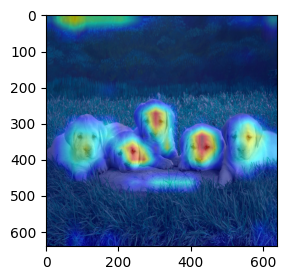

In [9]:
cam = EigenCAM(model, target_layers,task='od')
grayscale_cam = cam(rgb_img)[0, :, :]
cam_image = show_cam_on_image(img, grayscale_cam, use_rgb=True)
plt.imshow(cam_image)
plt.show()

# Test drone

In [10]:
model = YOLO('models/drone_area4_pe.pt')
# model = YOLO('models/best.pt')
# model = YOLO('models/yolo11x.pt')
model = model.cpu()

In [11]:
origin_img = cv2.imread('images/images/123.jpg')
img = cv2.resize(origin_img, (640, 640))
rgb_img = img.copy()
img = np.float32(img) / 255

In [13]:
target_layers =[model.model.model[-8]]


0: 640x640 41 pedestrians, 5 peoples, 5 bicycles, 36 cars, 4 vans, 2 trucks, 3 tricycles, 3 awning-tricycles, 19 motors, 6756.9ms
Speed: 4.9ms preprocess, 6756.9ms inference, 2.8ms postprocess per image at shape (1, 3, 640, 640)


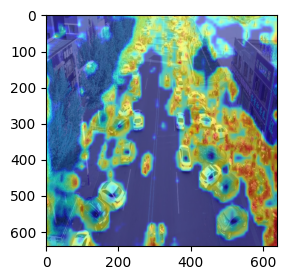

True

In [14]:
cam = EigenCAM(model, target_layers,task='od')
grayscale_cam = cam(rgb_img)[0, :, :]
cam_image = show_cam_on_image(img, grayscale_cam, use_rgb=True)

# Set figure size and DPI
# fig = plt.figure(figsize=(6, 6), dpi=400)  # Higher DPI for better resolution
plt.imshow(cam_image)
plt.show()

cv2.imwrite('./3.jpg', cam_image[:,:,[2,1,0]])


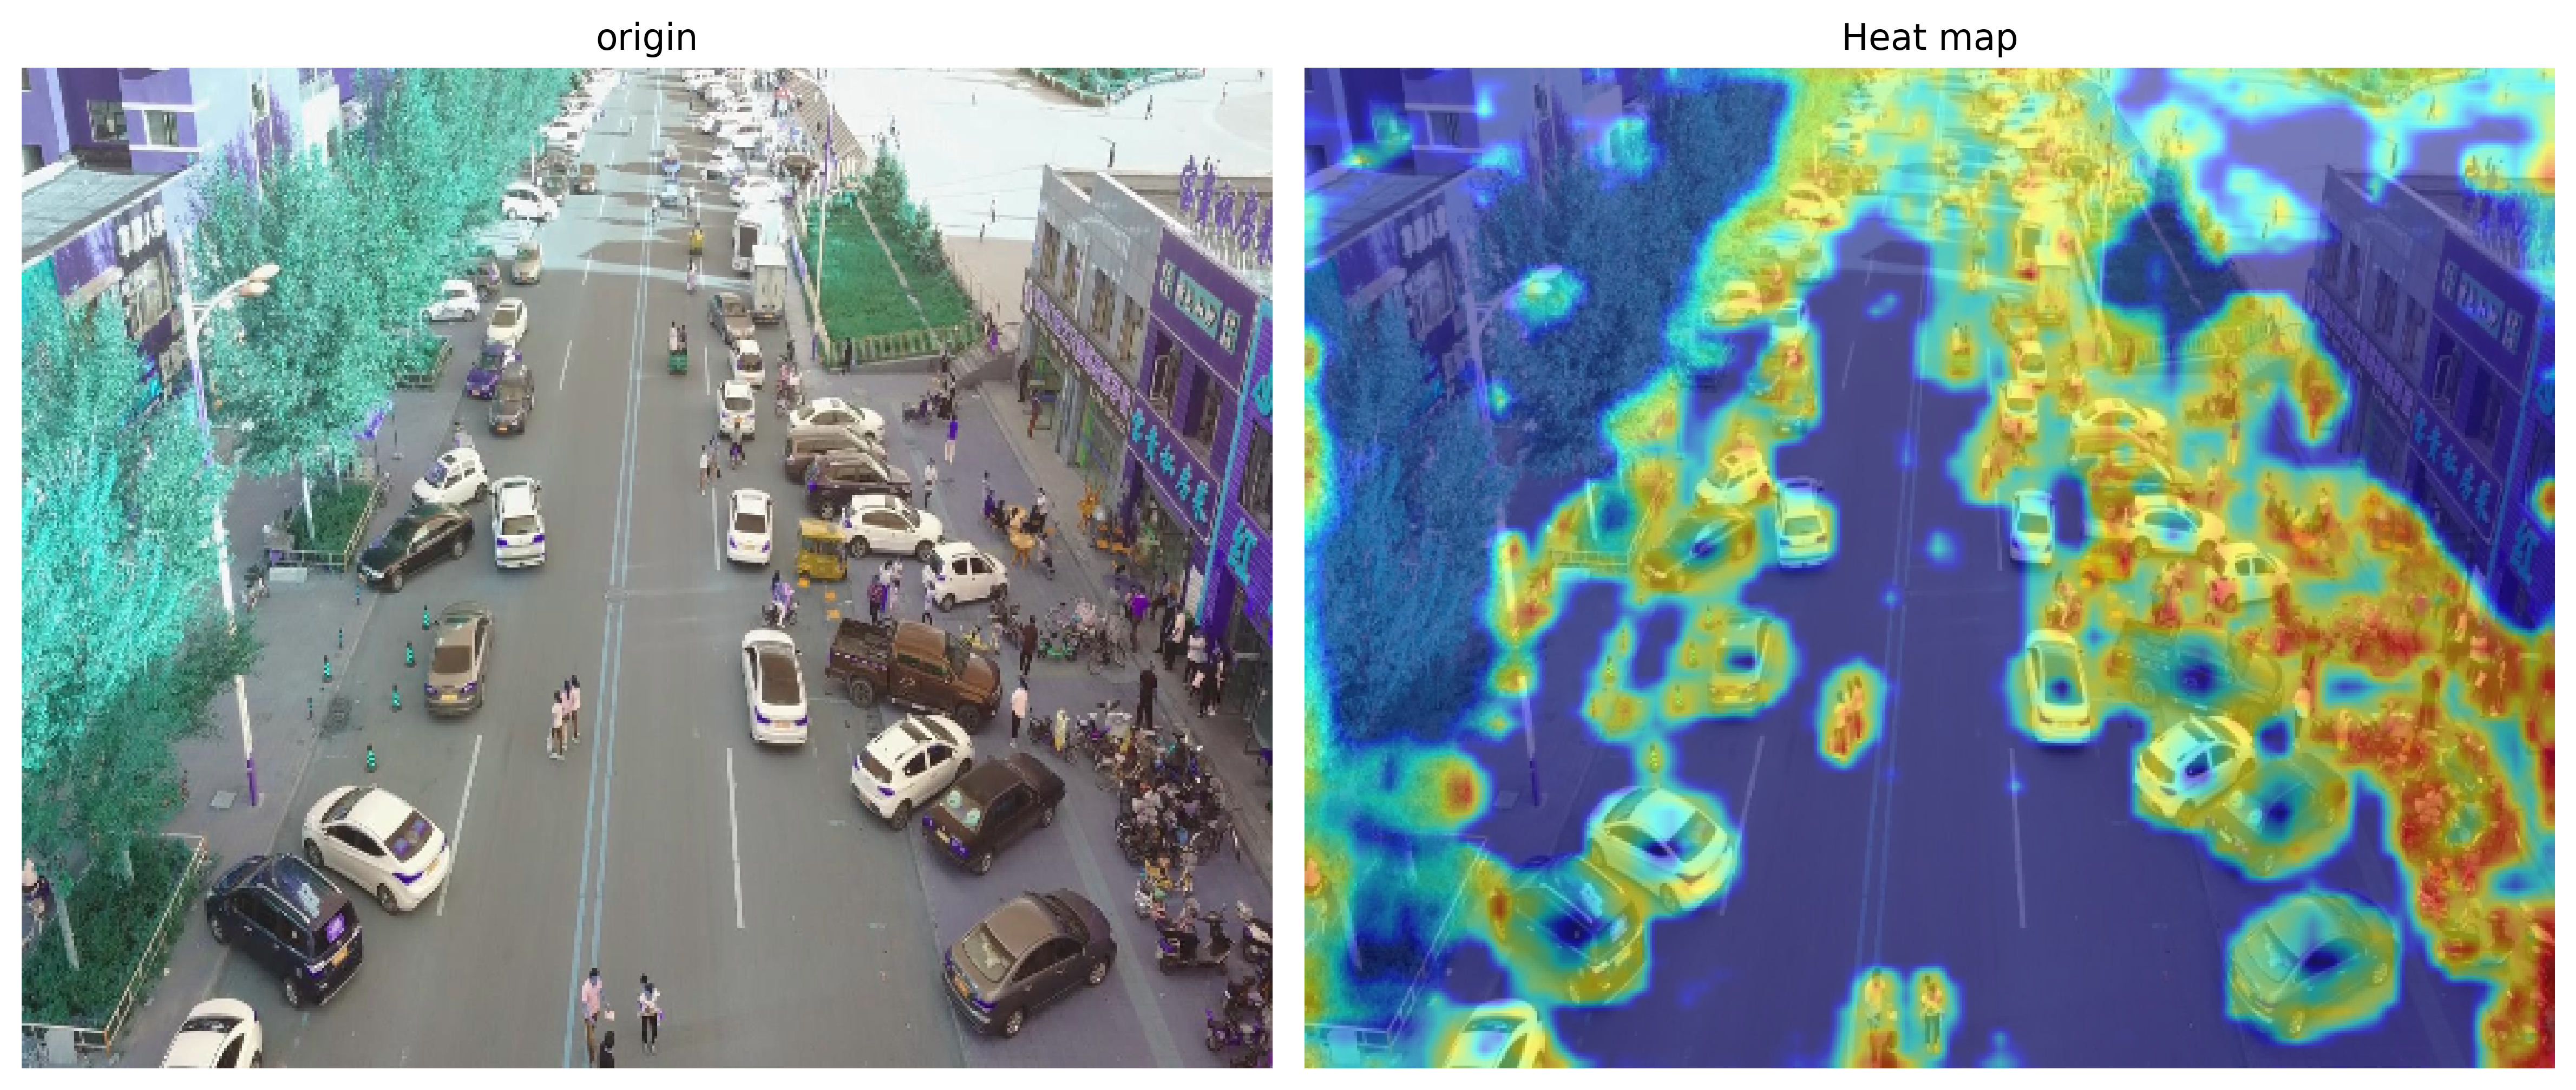

In [15]:
# Load two images
image1 = origin_img
image2 = cam_image

# Resize both images to the same dimensions
new_size = (500, 400)  # Width=400, Height=300
image1 = cv2.resize(image1, new_size)
image2 = cv2.resize(image2, new_size)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=400)

# Display the resized images
axes[0].imshow(image1)
axes[0].axis('off')
axes[0].set_title("origin")

axes[1].imshow(image2)
axes[1].axis('off')
axes[1].set_title("Heat map")

# Adjust spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()

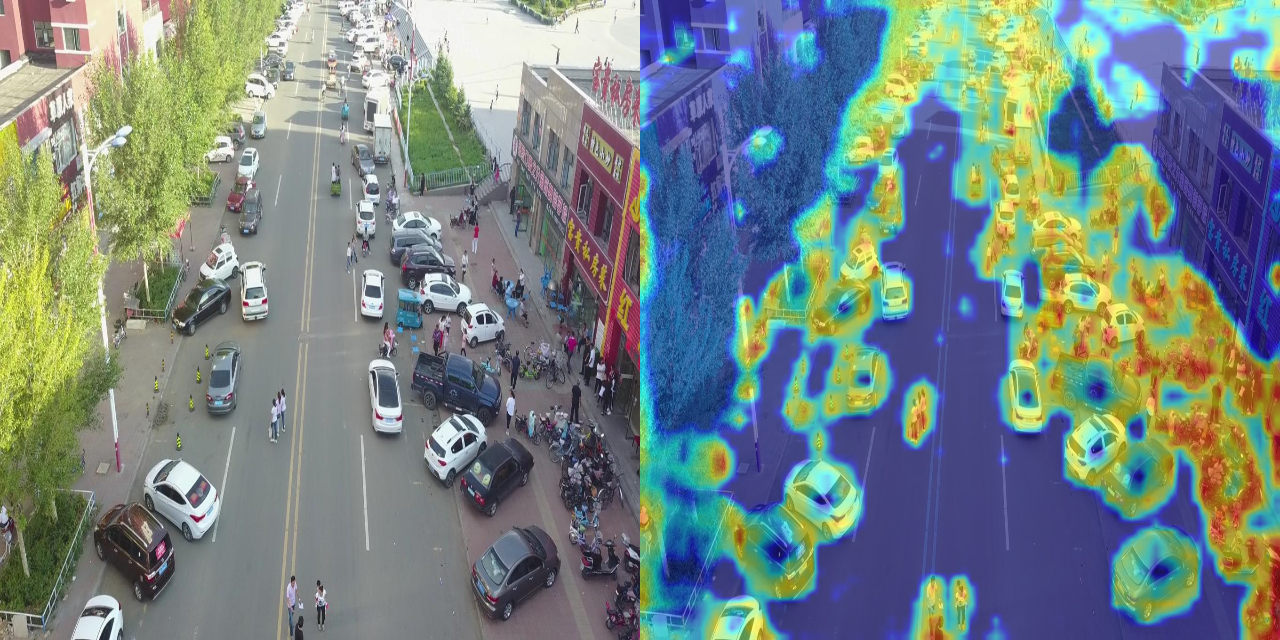

In [16]:
im = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2BGR)
Image.fromarray(np.hstack((im, cam_image)))

# Deal directory

In [12]:
import os

model = YOLO('models/best.pt')
# model = YOLO('models/drone_uavdt.pt')
# model = YOLO('models/yolo11x.pt')
model = model.cpu()

# List of common image file extensions
image_extensions = ['.jpg', '.jpeg', '.png']

# test_images_dir = 'test_images/uavdt'
test_images_dir = 'visdrone'
save_image_dir = 'visdrone/yolo12_mcam'
if not os.path.exists(save_image_dir):
    os.makedirs(save_image_dir)

for entry in os.listdir(test_images_dir):
    full_path = os.path.join(test_images_dir, entry)
    if not os.path.isfile(full_path):  # Check if it's a file
        continue
    # print(f"File: {entry}")
    # print(full_path, full_path)
    print('Deal file {}'.format(full_path))
    base_name, ext = os.path.splitext(entry)
    if ext not in ('.jpg', '.png'):
        continue
    # print(root, ext)

    origin_img = cv2.imread(full_path)
    img = cv2.resize(origin_img, (640, 640))
    rgb_img = img.copy()
    img = np.float32(img) / 255
    
    target_layers =[model.model.model[-8]]
    
    cam = EigenCAM(model, target_layers,task='od')
    grayscale_cam = cam(rgb_img)[0, :, :]
    cam_image = show_cam_on_image(img, grayscale_cam, use_rgb=True)
    
    # # Set figure size and DPI
    save_file_name = os.path.join(save_image_dir, base_name + '_heatmap.jpg')
    # print(save_file_name)
    fig = plt.figure(figsize=(6, 6), dpi=400)  # Higher DPI for better resolution
    # plt.imshow(cam_image)
    # plt.show()
    cv2.imwrite(save_file_name, cam_image[:,:,[2,1,0]]) 

print("Deal {} success---------------".format(test_images_dir))

Deal file visdrone/0000291_00601_d_0000871.jpg

0: 640x640 17 pedestrians, 2 peoples, 5 bicycles, 31 cars, 15 vans, 2 trucks, 2 tricycles, 2 buss, 5 motors, 3196.1ms
Speed: 4.2ms preprocess, 3196.1ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)
Deal file visdrone/0000070_05163_d_0000002.jpg

0: 640x640 100 pedestrians, 2 bicycles, 2 motors, 3172.9ms
Speed: 2.2ms preprocess, 3172.9ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Deal file visdrone/0000242_01475_d_0000007.jpg

0: 640x640 3 pedestrians, 2 peoples, 1 bicycle, 41 cars, 5 vans, 3 trucks, 1 tricycle, 2 awning-tricycles, 2 motors, 3179.1ms
Speed: 2.2ms preprocess, 3179.1ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Deal file visdrone/0000221_00999_d_0000003.jpg

0: 640x640 2 pedestrians, 3 peoples, 2 bicycles, 25 cars, 5 vans, 5 trucks, 2 buss, 3218.5ms
Speed: 2.2ms preprocess, 3218.5ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Deal file visdro

<Figure size 2400x2400 with 0 Axes>

<Figure size 2400x2400 with 0 Axes>

<Figure size 2400x2400 with 0 Axes>

<Figure size 2400x2400 with 0 Axes>

<Figure size 2400x2400 with 0 Axes>

<Figure size 2400x2400 with 0 Axes>